<a href="https://colab.research.google.com/github/bhavana3017/creditcard-fraud-detection-project./blob/main/creditcard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn


In [ ]:
import pandas as pd
df = pd.read_csv("/content/creditcard.csv")
print(df.head())
print(df['Class'].value_counts())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [ ]:
df['Class'].isnull().sum()


np.int64(1)

In [ ]:
df = df.dropna(subset=['Class'])

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test = scaler.transform(X_test)



In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (25018, 30) Test size: (10723, 30)


In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_sm, y_train_sm)
y_pred_lr = log_reg.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced")
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(scale_pos_weight=len(y_train_sm)/sum(y_train_sm), use_label_encoder=False, eval_metric="logloss")
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:04:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
import numpy as np


In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np   # <-- add this line

iso = IsolationForest(contamination=0.001, random_state=42)
iso.fit(X_train)
y_pred_iso = iso.predict(X_test)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def model_metrics(y_true, y_pred, model_name):
    print(f"\n{model_name}")
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred))


In [ ]:
model_metrics(y_test, y_pred_lr, "Logistic Regression")
model_metrics(y_test, y_pred_rf, "Random Forest")
model_metrics(y_test, y_pred_xgb, "XGBoost")
model_metrics(y_test, y_pred_iso, "Isolation Forest")



Logistic Regression
Precision: 0.0
Recall: 0.0
F1-score: 0.0
ROC-AUC: 0.49953236064347173

Random Forest
Precision: 0.011400651465798045
Recall: 0.9032258064516129
F1-score: 0.02251708886208283
ROC-AUC: 0.8380700674607485

XGBoost
Precision: 0.00429553264604811
Recall: 0.967741935483871
F1-score: 0.008553100498930863
ROC-AUC: 0.6586745592121936

Isolation Forest
Precision: 0.2
Recall: 0.06451612903225806
F1-score: 0.0975609756097561
ROC-AUC: 0.5318839530309064


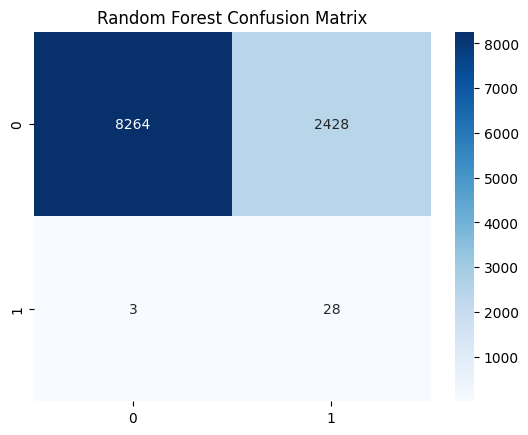

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

plot_confusion(y_test, y_pred_rf, "Random Forest")


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def model_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred)
    }

results = []
results.append(model_metrics(y_test, y_pred_lr, "Logistic Regression"))
results.append(model_metrics(y_test, y_pred_rf, "Random Forest"))
results.append(model_metrics(y_test, y_pred_xgb, "XGBoost"))
results.append(model_metrics(y_test, y_pred_iso, "Isolation Forest"))


In [ ]:
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)


                 Model  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression   0.000000  0.000000  0.000000  0.499532
1        Random Forest   0.011401  0.903226  0.022517  0.838070
2              XGBoost   0.004296  0.967742  0.008553  0.658675
3     Isolation Forest   0.200000  0.064516  0.097561  0.531884


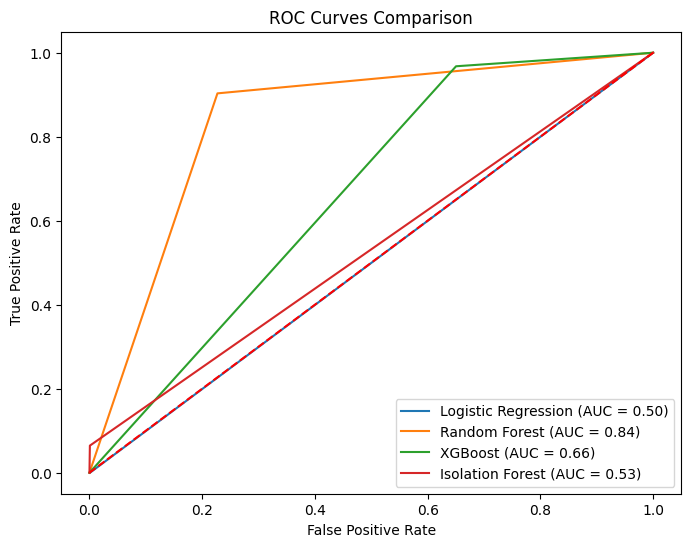

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_roc(y_true, y_pred, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.figure(figsize=(8,6))
plot_roc(y_test, y_pred_lr, "Logistic Regression")
plot_roc(y_test, y_pred_rf, "Random Forest")
plot_roc(y_test, y_pred_xgb, "XGBoost")
plot_roc(y_test, y_pred_iso, "Isolation Forest")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()


In [ ]:
import joblib
joblib.dump(rf, "random_forest_fraud_model.pkl")


['random_forest_fraud_model.pkl']

In [ ]:
rf_loaded = joblib.load("random_forest_fraud_model.pkl")
y_pred_loaded = rf_loaded.predict(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_sm, y_train_sm)



RandomForestClassifier()

In [ ]:
import joblib
joblib.dump(rf, "random_forest_fraud_model.pkl")


['random_forest_fraud_model.pkl']